## ***EXPOLATORY DATA ANALYSIS***

In [1]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import ipywidgets as widgets
from ipywidgets import interact


In [2]:
poland_df = pd.read_csv("data/poland_df.csv")
poland_df.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt
0,0.159290,0.46240,0.07773,1.1683,-44.853,0.467020,0.189480,0.82895,1.1223,0.38330,...,0.108990,0.41557,0.89101,0.001422,7.7928,4.9914,119.810,3.0465,3.0560,b'0'
1,-0.127430,0.46243,0.26917,1.7517,7.597,0.000925,-0.127430,1.16250,1.2944,0.53757,...,-0.089372,-0.23704,1.06250,0.150410,5.4327,3.4629,100.970,3.6150,3.4725,b'0'
2,0.070488,0.23570,0.52781,3.2393,125.680,0.163670,0.086895,2.87180,1.0574,0.67689,...,0.054286,0.10413,0.94571,0.000000,7.1070,3.3808,76.076,4.7978,4.7818,b'0'
3,0.136760,0.40538,0.31543,1.8705,19.115,0.504970,0.136760,1.45390,1.1144,0.58938,...,0.102630,0.23203,0.89737,0.073024,6.1384,4.2241,88.299,4.1337,4.6484,b'0'
4,-0.110080,0.69793,0.18878,1.2713,-15.344,0.000000,-0.110080,0.43282,1.7350,0.30207,...,0.439880,-0.36440,0.57153,0.000000,18.8010,2.7925,146.390,2.4934,15.0360,b'0'


# Getting nore information about the dataset
**This includes feature/column names, NaN Values, datatypes**

In [3]:
poland_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43405 entries, 0 to 43404
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Attr1     43397 non-null  float64
 1   Attr2     43397 non-null  float64
 2   Attr3     43397 non-null  float64
 3   Attr4     43271 non-null  float64
 4   Attr5     43316 non-null  float64
 5   Attr6     43397 non-null  float64
 6   Attr7     43397 non-null  float64
 7   Attr8     43311 non-null  float64
 8   Attr9     43396 non-null  float64
 9   Attr10    43397 non-null  float64
 10  Attr11    43361 non-null  float64
 11  Attr12    43271 non-null  float64
 12  Attr13    43278 non-null  float64
 13  Attr14    43397 non-null  float64
 14  Attr15    43369 non-null  float64
 15  Attr16    43310 non-null  float64
 16  Attr17    43311 non-null  float64
 17  Attr18    43397 non-null  float64
 18  Attr19    43277 non-null  float64
 19  Attr20    43278 non-null  float64
 20  Attr21    37551 non-null  fl

In [4]:
poland_df.describe()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr55,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64
count,43397.000000,43397.000000,43397.000000,43271.000000,4.331600e+04,43397.000000,43397.000000,43311.000000,43396.000000,43397.000000,...,4.340400e+04,4.327800e+04,43398.000000,4.332100e+04,43398.000000,4.125300e+04,43303.000000,4.327800e+04,43271.000000,42593.000000
mean,0.035160,0.590212,0.114431,6.314702,-3.853466e+02,-0.056107,0.093478,12.640779,2.652166,0.626868,...,7.672188e+03,-2.621959e+01,-0.010510,3.002644e+01,1.333288,4.480858e+02,17.033202,1.502328e+03,9.343074,72.788592
std,2.994109,5.842748,5.439429,295.434425,6.124303e+04,7.201326,5.713075,505.894281,62.932732,14.670597,...,7.005310e+04,5.327862e+03,13.674072,5.334454e+03,122.104445,3.234560e+04,553.049406,1.392667e+05,124.177354,2369.339482
min,-463.890000,-430.870000,-479.960000,-0.403110,-1.190300e+07,-508.410000,-517.480000,-141.410000,-3.496000,-479.910000,...,-1.805200e+06,-1.108300e+06,-1667.300000,-1.986900e+02,-327.970000,-1.244000e+01,-12.656000,-2.336500e+06,-1.543200,-10677.000000
25%,0.003429,0.268980,0.021521,1.049500,-4.908000e+01,0.000000,0.005776,0.430275,1.018500,0.295470,...,2.755425e+01,9.348500e-03,0.014649,8.753200e-01,0.000000,5.545500e+00,4.510150,4.214400e+01,3.097650,2.176800
50%,0.049660,0.471900,0.196610,1.569800,-1.034500e+00,0.000000,0.059634,1.070400,1.195350,0.505970,...,1.088350e+03,5.294300e-02,0.119670,9.509600e-01,0.006366,9.791700e+00,6.636300,7.132600e+01,5.087600,4.282500
75%,0.129580,0.688320,0.403390,2.787450,5.063425e+01,0.089446,0.150880,2.615700,2.062500,0.709100,...,4.993325e+03,1.290975e-01,0.284605,9.926400e-01,0.236052,2.018100e+01,10.394500,1.172200e+02,8.598850,9.776200
max,94.280000,480.960000,28.336000,53433.000000,1.250100e+06,543.250000,649.230000,53432.000000,9742.300000,1099.500000,...,6.123700e+06,2.931500e+02,552.640000,1.108300e+06,23853.000000,4.818700e+06,108000.000000,2.501600e+07,23454.000000,294770.000000


# The target 


In [5]:
poland_df["bankrupt"].head()


0    b'0'
1    b'0'
2    b'0'
3    b'0'
4    b'0'
Name: bankrupt, dtype: object

In [6]:
#Making the target to have classes 0 and 1
poland_df["bankrupt"] = poland_df["bankrupt"].str.replace(r"b'|'", "", regex=True).astype(int)
poland_df["bankrupt"].head()

0    0
1    0
2    0
3    0
4    0
Name: bankrupt, dtype: int64

In [7]:
poland_df.tail()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt
43400,0.018371,0.47410,-0.13619,0.60839,-18.4490,0.018371,0.018371,0.972030,1.01210,0.460840,...,0.011909,0.039866,0.98809,0.27414,73.505,79.2370,31.268,11.6730,5.14890,1
43401,-0.013359,0.58354,-0.02265,0.92896,-42.2320,-0.013359,-0.015036,0.562890,0.98904,0.328470,...,-0.011082,-0.040671,1.01110,0.80592,10.599,7.1740,94.092,3.8792,1.75720,1
43402,0.006338,0.50276,0.43923,1.87360,9.7417,0.006338,0.012022,0.983560,1.00830,0.494490,...,0.008258,0.012817,0.99174,0.00000,10.470,6.0759,51.019,7.1542,62.00100,1
43403,-0.041643,0.84810,-0.12852,0.57485,-121.9200,0.000000,-0.036795,0.179010,0.42138,0.151820,...,-0.232720,-0.274290,0.98788,3.59310,39.703,3.1420,261.850,1.3939,0.51005,1
43404,0.014946,0.94648,0.03211,1.03630,-20.5810,0.000000,0.015260,0.056357,2.96940,0.053341,...,0.015705,0.280210,0.97443,1.17920,15.036,4.1741,108.640,3.3599,35.11800,1


# Class Distribution 

In [8]:
poland_df["bankrupt"].value_counts(normalize=True)

bankrupt
0    0.951826
1    0.048174
Name: proportion, dtype: float64

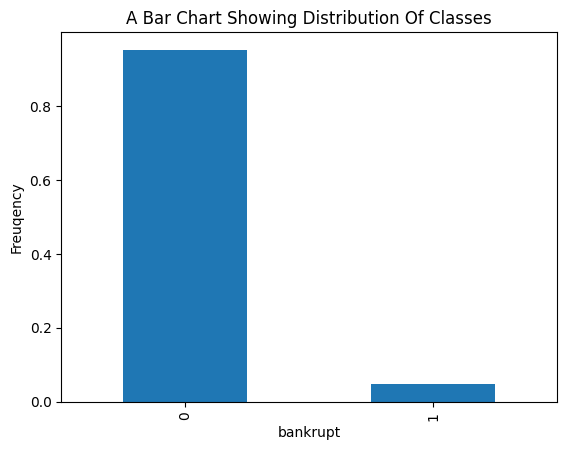

In [9]:
# A Plot showing Distribution of classes
poland_df["bankrupt"].value_counts(normalize=True).plot(kind="bar")
plt.title("A Bar Chart Showing Distribution Of Classes")
plt.ylabel("Freuqency");

***From the above we can conclude that with the given data more companies have no threat of running bankrupt whereas there are a few with chances of running bankrupt***

# Detecting Outliers using Attr27 

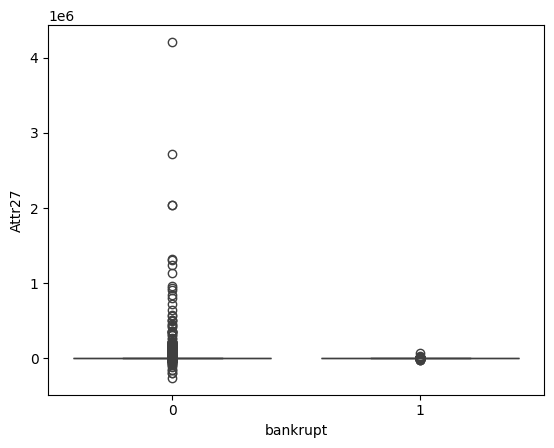

In [10]:
sns.boxplot(x="bankrupt", y="Attr27", data=poland_df);

In [11]:
# Clipping data (Removing Outliers when the data is skewed)
q1,q2 = poland_df["Attr27"].quantile([0.1,0.9])
poland_df["Attr27"] = poland_df["Attr27"].between(q1,q2)

# The correlation heat map

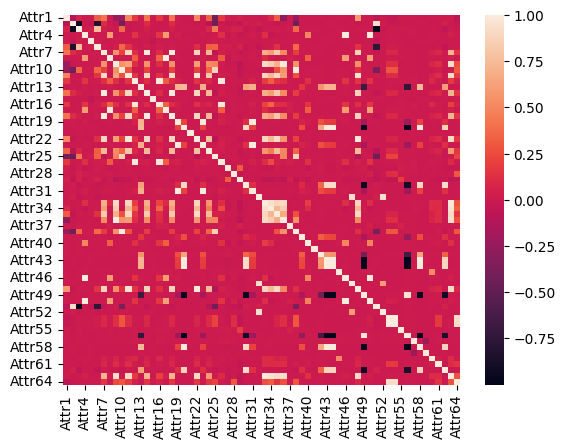

In [12]:
corr = poland_df.drop(columns="bankrupt").corr()
sns.heatmap(corr);

**Addressing Class Imbalance**

**1. The Oversampling Techniques**

In [13]:
#splitting the Data
X = poland_df.drop(columns="bankrupt")
y = poland_df["bankrupt"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
# Applying Random Oversampler on training data only
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

In [15]:
#Checking for the escence of OverSampling
y_train_over.value_counts(normalize=True)

bankrupt
0    0.5
1    0.5
Name: proportion, dtype: float64

**Saving the file with the the updated target!**

In [16]:
# Saving the poland_df to csv with the target class being 0 and 1
poland_df.to_csv("data/poland_df1.csv", index=False)
df = pd.read_csv("data/poland_df1.csv")
df.tail()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,bankrupt
43400,0.018371,0.47410,-0.13619,0.60839,-18.4490,0.018371,0.018371,0.972030,1.01210,0.460840,...,0.011909,0.039866,0.98809,0.27414,73.505,79.2370,31.268,11.6730,5.14890,1
43401,-0.013359,0.58354,-0.02265,0.92896,-42.2320,-0.013359,-0.015036,0.562890,0.98904,0.328470,...,-0.011082,-0.040671,1.01110,0.80592,10.599,7.1740,94.092,3.8792,1.75720,1
43402,0.006338,0.50276,0.43923,1.87360,9.7417,0.006338,0.012022,0.983560,1.00830,0.494490,...,0.008258,0.012817,0.99174,0.00000,10.470,6.0759,51.019,7.1542,62.00100,1
43403,-0.041643,0.84810,-0.12852,0.57485,-121.9200,0.000000,-0.036795,0.179010,0.42138,0.151820,...,-0.232720,-0.274290,0.98788,3.59310,39.703,3.1420,261.850,1.3939,0.51005,1
43404,0.014946,0.94648,0.03211,1.03630,-20.5810,0.000000,0.015260,0.056357,2.96940,0.053341,...,0.015705,0.280210,0.97443,1.17920,15.036,4.1741,108.640,3.3599,35.11800,1
